# **Understanding features in the dataset:**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('Production System Dataset.csv')
df

,timestamp,machine_id,machine_type,temperature,vibration_level,power_consumption,pressure,material_flow_rate,cycle_time,error_rate,downtime,maintenance_flag,efficiency_score,production_status
0,2025-03-10 08:00:00,M003,Welder,78.302879,2.043751,23.059855,5.088076,20.011026,118.146510,0.883246,0,0,11.675410,0
1,2025-03-10 08:01:00,M004,Conveyor,80.877076,2.175590,16.012814,5.412956,18.375739,123.062058,0.777073,38,0,3.292706,0
2,2025-03-10 08:02:00,M001,Drill,71.315418,2.154465,15.759164,5.769405,17.112107,122.754064,0.757374,37,0,5.762582,0
3,2025-03-10 08:03:00,M003,Conveyor,76.496198,2.245978,16.490268,4.618784,21.090684,118.990270,0.796481,39,0,0.851911,0
4,2025-03-10 08:04:00,M003,CNC,73.612202,2.097302,18.064286,5.431250,20.868592,113.749872,0.813361,0,0,18.663902,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2455,2025-03-12 00:55:00,M001,Conveyor,80.585617,1.744735,14.463169,5.034138,20.826884,113.009590,0.652834,0,0,34.716573,0
2456,2025-03-12 00:56:00,M003,Drill,78.171483,2.732367,19.990335,4.971981,18.291071,132.987186,0.988201,0,0,1.179945,0
2457,2025-03-12 00:57:00,M003,Welder,78.782847,2.131138,19.874735,5.290168,22.551457,114.350925,0.847650,0,0,15.234984,0
2458,2025-03-12 00:58:00,M001,Drill,77.939129,2.027617,19.660323,4.924919,22.706616,117.406875,0.807874,0,0,19.212551,0


In [5]:
df.describe()

,temperature,vibration_level,power_consumption,pressure,material_flow_rate,cycle_time,error_rate,downtime,maintenance_flag,efficiency_score,production_status
count,2411.000000,2404.000000,2405.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.0
mean,77.938602,2.230957,18.422577,4.993933,20.032925,120.071115,0.794854,12.313008,0.059350,15.577832,0.0
std,3.944714,1.117706,2.669908,0.391494,1.511022,5.057995,0.085257,18.408838,0.236326,10.763130,0.0
min,66.136665,1.048872,10.326689,3.431040,15.376157,101.823999,0.540933,0.000000,0.000000,0.000000,0.0
25%,75.240313,1.806224,16.741559,4.732438,19.017601,116.624522,0.735993,0.000000,0.000000,5.760614,0.0
50%,77.734034,2.005956,18.159299,4.992426,20.031692,120.089570,0.789355,0.000000,0.000000,17.017636,0.0
75%,80.165885,2.230489,19.699169,5.251234,21.050319,123.567379,0.842145,36.000000,0.000000,23.980193,0.0
max,94.569177,9.109769,34.368410,6.351107,25.143366,142.395421,1.000000,50.000000,1.000000,45.906702,0.0


array([[<Axes: title={'center': 'temperature'}>,
        <Axes: title={'center': 'vibration_level'}>,
        <Axes: title={'center': 'power_consumption'}>],
       [<Axes: title={'center': 'pressure'}>,
        <Axes: title={'center': 'material_flow_rate'}>,
        <Axes: title={'center': 'cycle_time'}>],
       [<Axes: title={'center': 'error_rate'}>,
        <Axes: title={'center': 'downtime'}>,
        <Axes: title={'center': 'maintenance_flag'}>],
       [<Axes: title={'center': 'efficiency_score'}>,
        <Axes: title={'center': 'production_status'}>, <Axes: >]],
      dtype=object)

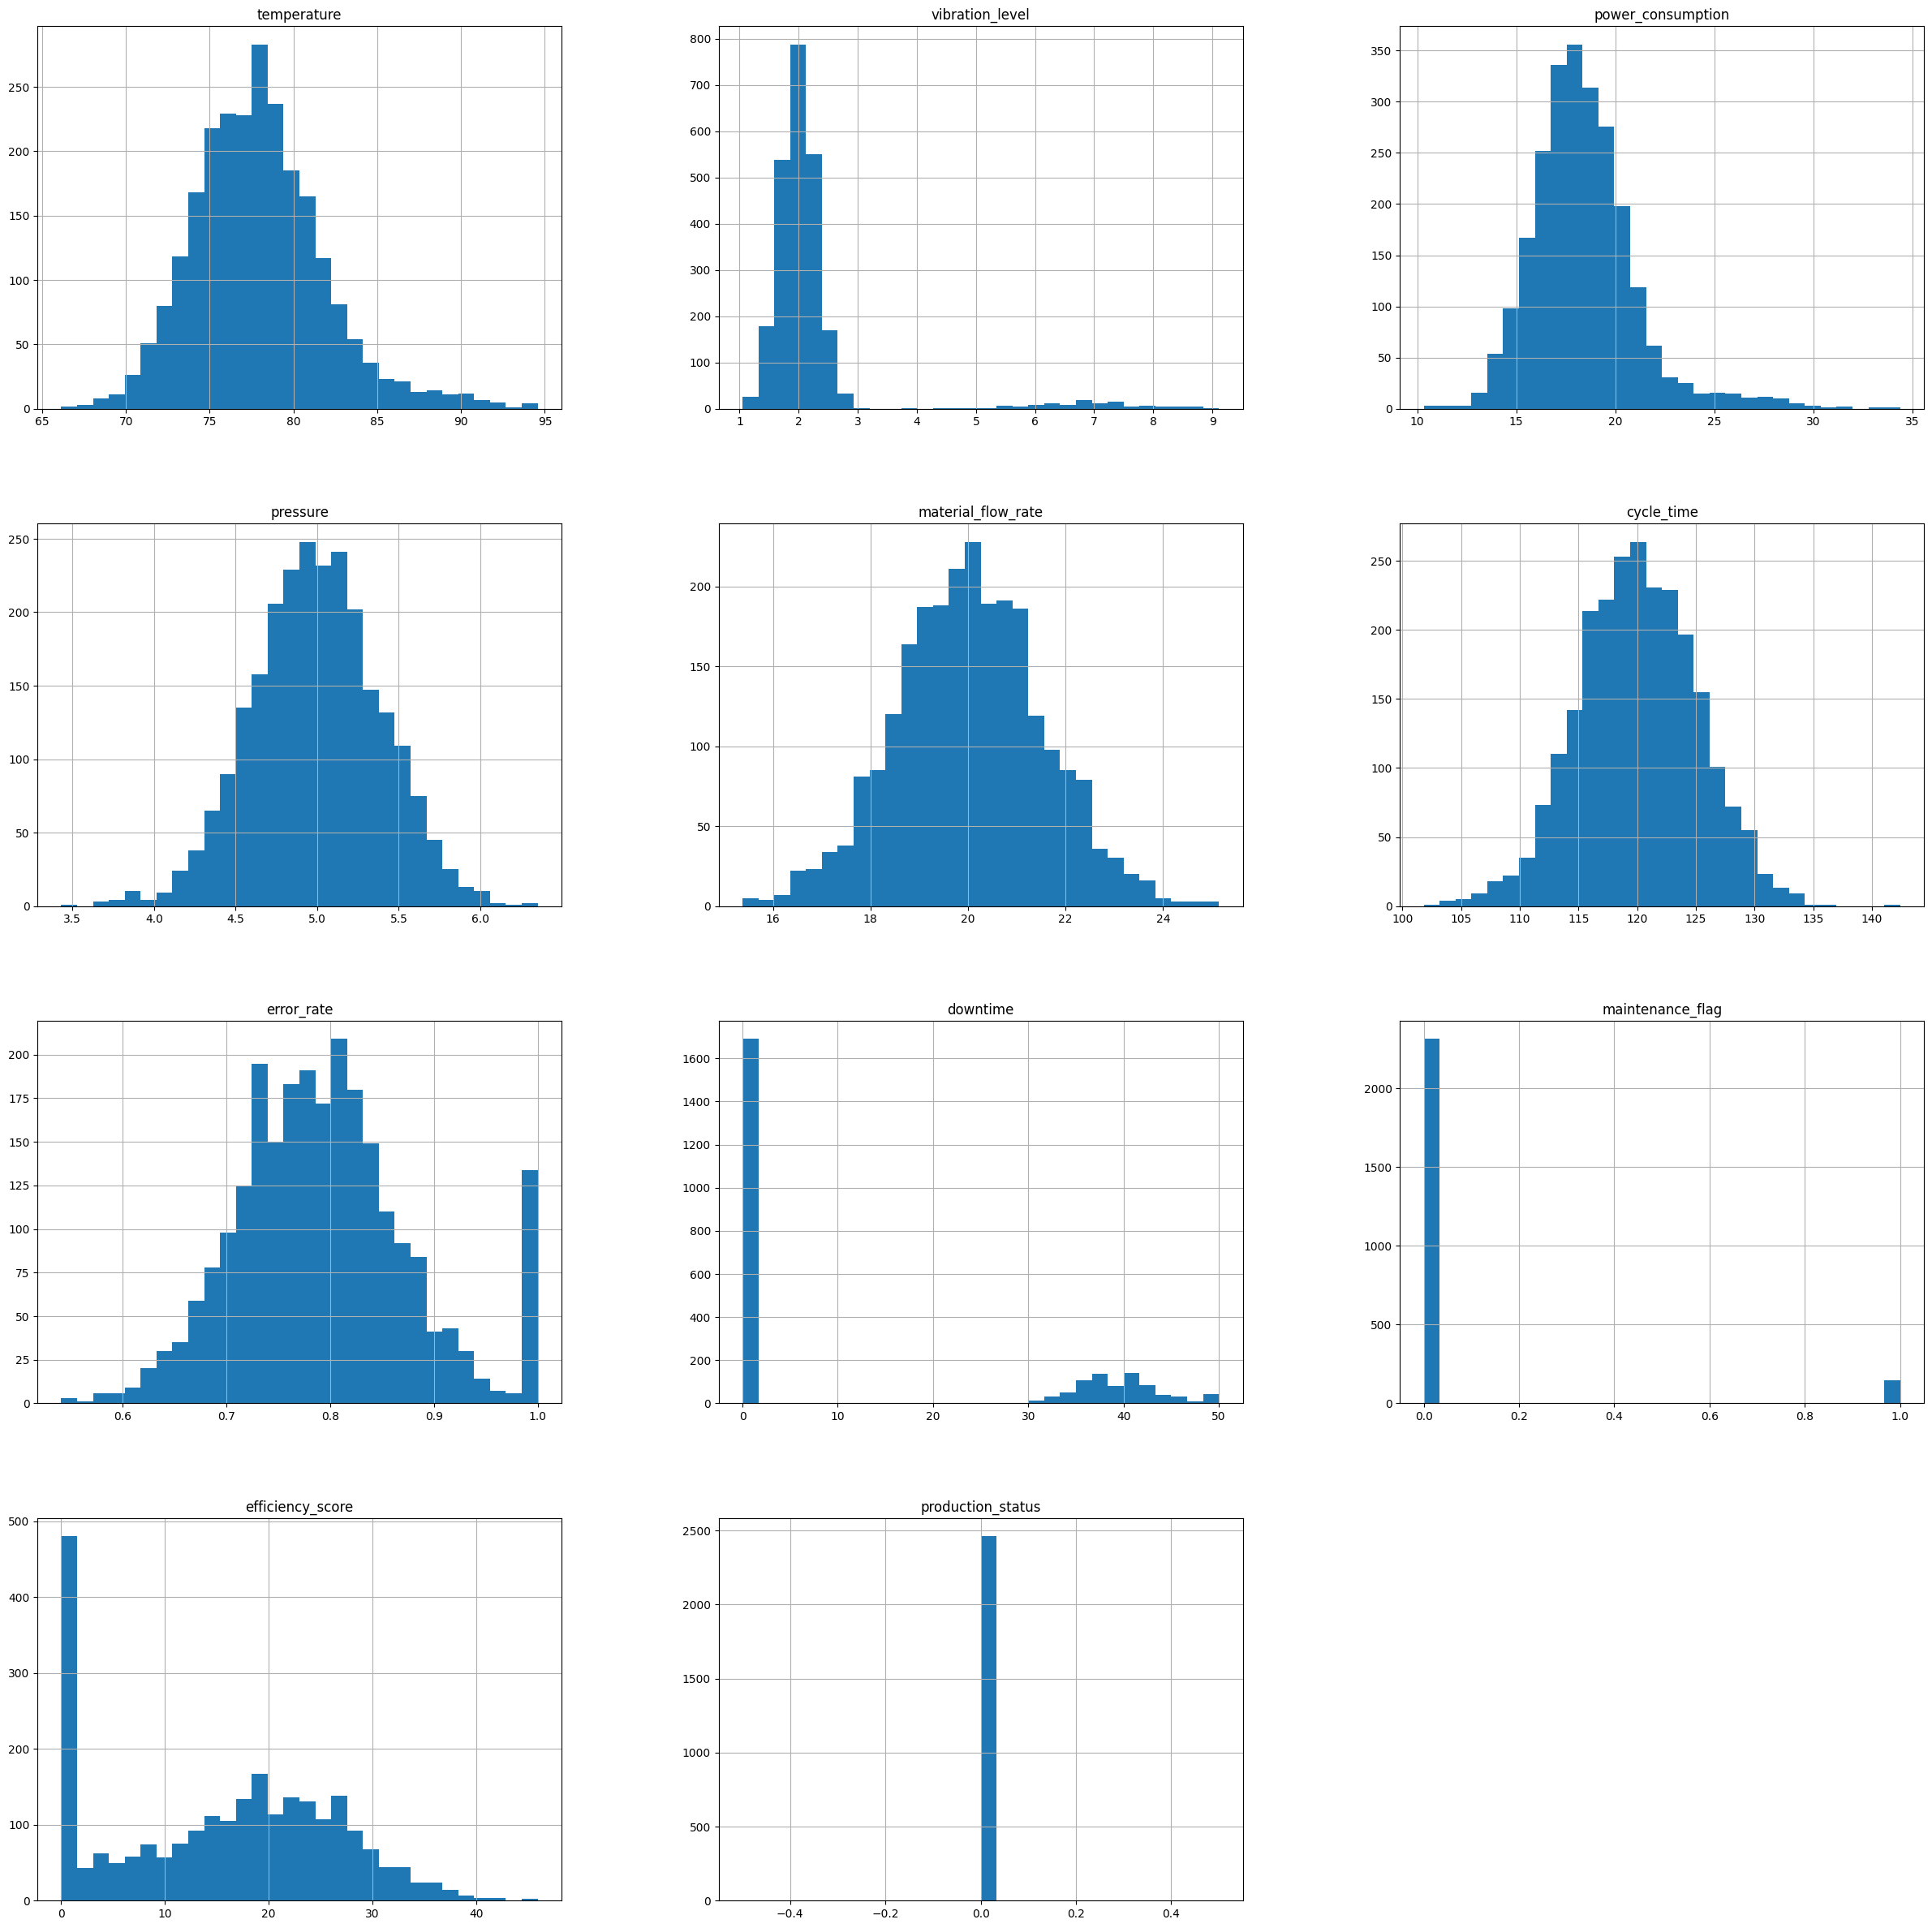

In [6]:
df.hist(bins=30, figsize=(30,30))

In [7]:
df['machine_id'].value_counts()

,count
machine_id,
M001,647
M003,611
M002,605
M004,597


In [8]:
df['machine_type'].value_counts()

,count
machine_type,
Welder,638
CNC,630
Conveyor,616
Drill,576


Thus, machine_id != machine type

In [9]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
temperature,49
vibration_level,56
power_consumption,55


In [10]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
2455,False
2456,False
2457,False
2458,False


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2460 entries, 0 to 2459
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   timestamp           2460 non-null   object 
 1   machine_id          2460 non-null   object 
 2   machine_type        2460 non-null   object 
 3   temperature         2411 non-null   float64
 4   vibration_level     2404 non-null   float64
 5   power_consumption   2405 non-null   float64
 6   pressure            2460 non-null   float64
 7   material_flow_rate  2460 non-null   float64
 8   cycle_time          2460 non-null   float64
 9   error_rate          2460 non-null   float64
 10  downtime            2460 non-null   int64  
 11  maintenance_flag    2460 non-null   int64  
 12  efficiency_score    2460 non-null   float64
 13  production_status   2460 non-null   int64  
dtypes: float64(8), int64(3), object(3)
memory usage: 269.2+ KB


# **Preprocessing & Split dataset:**
* Group dataset by 'machine_type'.
* Fill missing values with average from their respective columns within their grouping.
* One-hot encoding for 'machine_id' & 'machine_type'.
* Split to Training & Validation Datasets

In [12]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [13]:
target_columns = ['error_rate', 'downtime', 'maintenance_flag',
                  'efficiency_score', 'production_status']

sensor_columns = ['temperature', 'vibration_level', 'power_consumption',
                  'pressure', 'material_flow_rate', 'cycle_time']

In [14]:
df_processed = df.copy()
df_processed

,timestamp,machine_id,machine_type,temperature,vibration_level,power_consumption,pressure,material_flow_rate,cycle_time,error_rate,downtime,maintenance_flag,efficiency_score,production_status
0,2025-03-10 08:00:00,M003,Welder,78.302879,2.043751,23.059855,5.088076,20.011026,118.146510,0.883246,0,0,11.675410,0
1,2025-03-10 08:01:00,M004,Conveyor,80.877076,2.175590,16.012814,5.412956,18.375739,123.062058,0.777073,38,0,3.292706,0
2,2025-03-10 08:02:00,M001,Drill,71.315418,2.154465,15.759164,5.769405,17.112107,122.754064,0.757374,37,0,5.762582,0
3,2025-03-10 08:03:00,M003,Conveyor,76.496198,2.245978,16.490268,4.618784,21.090684,118.990270,0.796481,39,0,0.851911,0
4,2025-03-10 08:04:00,M003,CNC,73.612202,2.097302,18.064286,5.431250,20.868592,113.749872,0.813361,0,0,18.663902,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2455,2025-03-12 00:55:00,M001,Conveyor,80.585617,1.744735,14.463169,5.034138,20.826884,113.009590,0.652834,0,0,34.716573,0
2456,2025-03-12 00:56:00,M003,Drill,78.171483,2.732367,19.990335,4.971981,18.291071,132.987186,0.988201,0,0,1.179945,0
2457,2025-03-12 00:57:00,M003,Welder,78.782847,2.131138,19.874735,5.290168,22.551457,114.350925,0.847650,0,0,15.234984,0
2458,2025-03-12 00:58:00,M001,Drill,77.939129,2.027617,19.660323,4.924919,22.706616,117.406875,0.807874,0,0,19.212551,0


Finding mean value of each sensor in each 'machine_type'

In [15]:
machine_type_means = df_processed.groupby('machine_type')[sensor_columns].mean()
machine_type_means

,temperature,vibration_level,power_consumption,pressure,material_flow_rate,cycle_time
machine_type,,,,,,
CNC,77.698575,2.178295,18.274583,4.982962,20.025625,119.877706
Conveyor,78.018933,2.324565,18.586657,4.993909,20.024496,120.343962
Drill,77.953621,2.205588,18.393664,5.016262,20.074424,120.286679
Welder,78.085166,2.216285,18.437097,4.984631,20.010806,119.804045


Filling the missing values with the mean values

In [16]:
for machine_type in df_processed['machine_type'].unique():
    mask = df_processed['machine_type'] == machine_type
    for col in sensor_columns:
        mean_value = machine_type_means.loc[machine_type, col]
        df_processed.loc[mask, col] = df_processed.loc[mask, col].fillna(mean_value)

print("\nRemaining missing values in sensor columns:")
df_processed[sensor_columns].isnull().sum()


Remaining missing values in sensor columns:


,0
temperature,0
vibration_level,0
power_consumption,0
pressure,0
material_flow_rate,0
cycle_time,0


Split by 'machine_type' and One-hot encode both 'machine_id' and 'machine_type'

In [21]:
machine_types = df_processed['machine_type'].unique()
print(f"\nMachine types found: {machine_types}")


Machine types found: ['Welder' 'Conveyor' 'Drill' 'CNC']


In [24]:
machine_type_data = {}

In [25]:
for machine_type in machine_types:
    type_df = df_processed[df_processed['machine_type'] == machine_type].copy()

    type_df = type_df.sort_values('timestamp').reset_index(drop=True)

    type_df_encoded = pd.get_dummies(type_df,
                                     columns=['machine_id'],
                                     prefix='machine',
                                     drop_first=False)

    machine_id_columns = [col for col in type_df_encoded.columns if col.startswith('machine_')]

    feature_columns = sensor_columns + machine_id_columns

    X = type_df_encoded[feature_columns].copy()
    y = type_df_encoded[target_columns].copy()

    machine_type_data[machine_type] = {
        'X': X,
        'y': y,
        'timestamps': type_df_encoded['timestamp'].copy(),
        'machine_id_columns': machine_id_columns,
        'n_samples': len(X)
    }

    print(f"\n{machine_type}: {len(X)} samples, {len(feature_columns)} features")


Welder: 638 samples, 11 features

Conveyor: 616 samples, 11 features

Drill: 576 samples, 11 features

CNC: 630 samples, 11 features


In [26]:
for machine_type, data in machine_type_data.items():
    combined_df = pd.concat([data['X'], data['y']], axis=1)

    combined_df['timestamp'] = data['timestamps']

    filename = f"preprocessed_{machine_type}.csv"

    combined_df.to_csv(filename, index=False)

    print(f"Saved {filename} with {len(combined_df)} rows")

Saved preprocessed_Welder.csv with 638 rows
Saved preprocessed_Conveyor.csv with 616 rows
Saved preprocessed_Drill.csv with 576 rows
Saved preprocessed_CNC.csv with 630 rows
